--- Dataset Overview ---
<class 'pandas.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               2920 non-null   str    
 1   product_name       2920 non-null   str    
 2   cost_price         2920 non-null   float64
 3   base_price         2920 non-null   float64
 4   competitor_price   2920 non-null   float64
 5   historical_price   2920 non-null   float64
 6   inventory_level    2920 non-null   int64  
 7   days_to_expiry     2920 non-null   float64
 8   is_weekend         2920 non-null   int64  
 9   is_holiday         2920 non-null   int64  
 10  weather_condition  2920 non-null   int64  
 11  items_sold         2920 non-null   int64  
 12  revenue            2920 non-null   float64
 13  profit             2920 non-null   float64
 14  stock_out_occured  2920 non-null   int64  
 15  inventory_wastage  2920 non-null   int64  
dtypes: float64

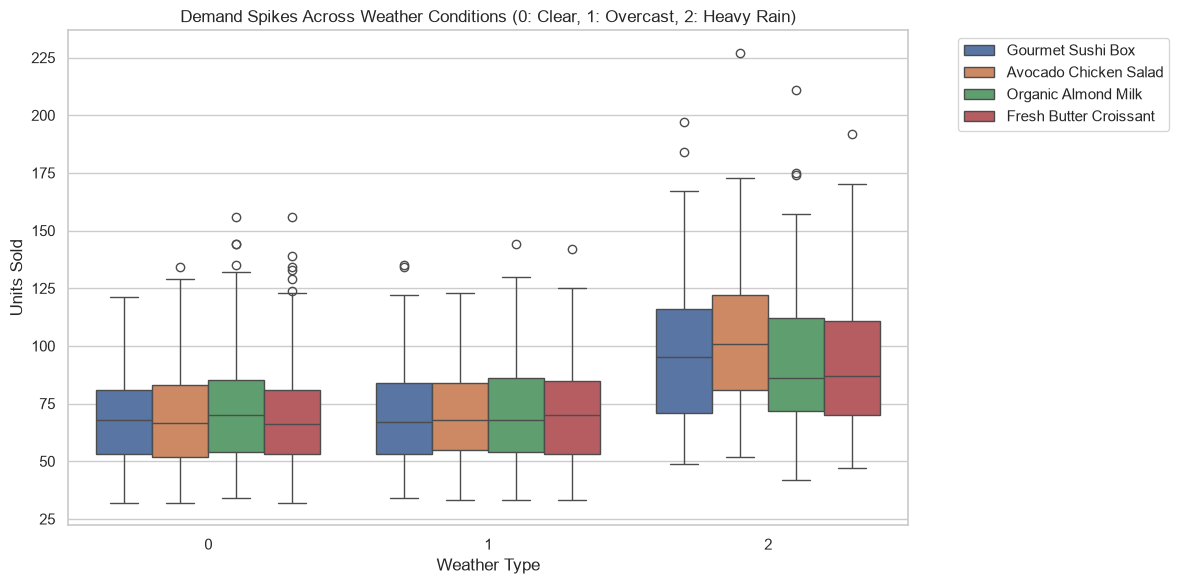

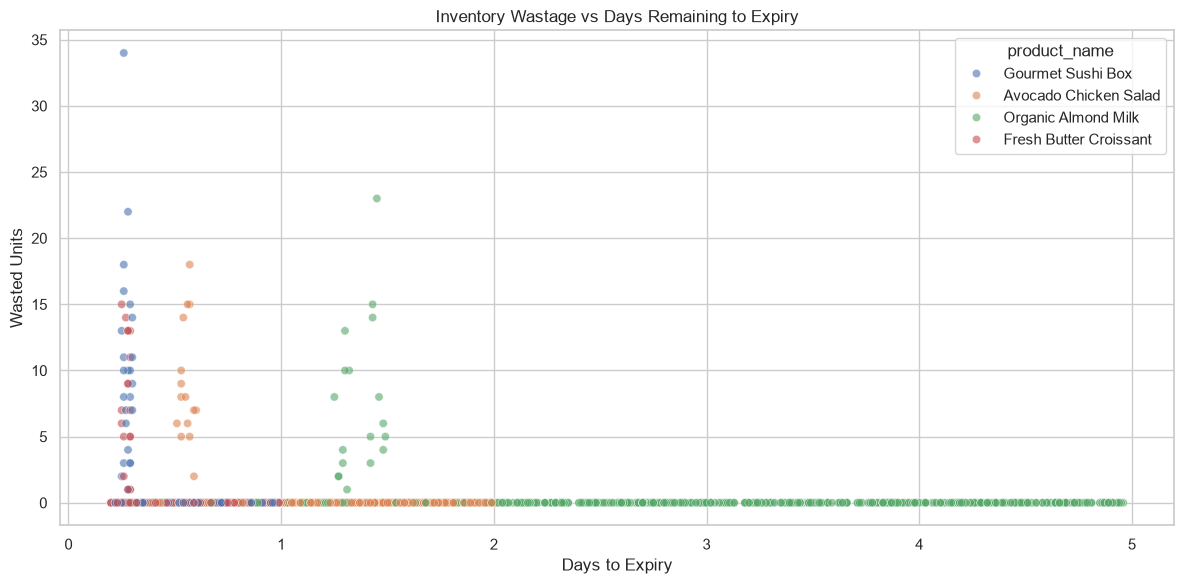

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting styles
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# 1. Load the synthesized matrix
df = pd.read_csv('../data/perishable_sales_data.csv')

print("--- Dataset Overview ---")
print(df.info())
print("\n--- First 3 Rows ---")
print(df.head(3))

# 2. Analyze Price Elasticity: Create a new tracking metric
# Price Ratio = Our Price / Competitor Price
df['price_ratio'] = df['historical_price'] / df['competitor_price']

print("\n--- Correlation of Pricing Matrix to Items Sold ---")
print(df[['price_ratio', 'days_to_expiry', 'weather_condition', 'items_sold', 'profit']].corr()['items_sold'])

# 3. Let's visualize the impact of Weather on Items Sold
plt.figure()
sns.boxplot(data=df, x='weather_condition', y='items_sold', hue='product_name')
plt.title('Demand Spikes Across Weather Conditions (0: Clear, 1: Overcast, 2: Heavy Rain)')
plt.xlabel('Weather Type')
plt.ylabel('Units Sold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../notebooks/weather_impact.png')
plt.show()

# 4. Analyze Expiry Markdowns vs Wastage
plt.figure()
sns.scatterplot(data=df, x='days_to_expiry', y='inventory_wastage', hue='product_name', alpha=0.6)
plt.title('Inventory Wastage vs Days Remaining to Expiry')
plt.xlabel('Days to Expiry')
plt.ylabel('Wasted Units')
plt.tight_layout()
plt.savefig('../notebooks/wastage_analysis.png')
plt.show()